# 📊 Sales Data Analysis

## CloudExify Summer Internship 2026

### Project 1

---

**Prepared By:** Laiba Fatima

**Internship:** Data Science – Month 1

**Language:** Python

**Libraries:** Pandas, NumPy, Matplotlib

**Environment:** Jupyter Notebook

---

## 🎯 Project Objective

The objective of this project is to analyze sales data, perform data cleaning, explore insights, and visualize the results using Python.

## Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pltaa

## Load Dataset

In [7]:
df = pd.read_csv("../data/sales_data.csv")
df.head()

,Sale_ID,Product,Category,Region,Units,Unit_Price,Amount,Date
0,S001,Laptop,Electronics,Lahore,2,80000.0,160000.0,7/1/2026
1,S002,Mouse,Accessories,Karachi,5,1200.0,6000.0,7/3/2026
2,S003,Keyboard,Accessories,Multan,3,1500.0,4500.0,7/5/2026
3,S004,CPU,Computer Parts,Islamabad,1,50000.0,50000.0,7/8/2026
4,S005,Headphone,Accessories,Lahore,4,3000.0,12000.0,7/10/2026


## Dataset Overview

In [8]:
print("First 5 row")
display(df.head())

print("\n Dataset shape: ")
print(df.shape)

print("\nDataset information: ")
df.info()

print("\nStatical summary: ")
display(df.describe())

First 5 row


,Sale_ID,Product,Category,Region,Units,Unit_Price,Amount,Date
0,S001,Laptop,Electronics,Lahore,2,80000.0,160000.0,7/1/2026
1,S002,Mouse,Accessories,Karachi,5,1200.0,6000.0,7/3/2026
2,S003,Keyboard,Accessories,Multan,3,1500.0,4500.0,7/5/2026
3,S004,CPU,Computer Parts,Islamabad,1,50000.0,50000.0,7/8/2026
4,S005,Headphone,Accessories,Lahore,4,3000.0,12000.0,7/10/2026



 Dataset shape: 
(20, 8)

Dataset information: 
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Sale_ID     20 non-null     str    
 1   Product     20 non-null     str    
 2   Category    20 non-null     str    
 3   Region      19 non-null     str    
 4   Units       20 non-null     int64  
 5   Unit_Price  19 non-null     float64
 6   Amount      19 non-null     float64
 7   Date        20 non-null     str    
dtypes: float64(2), int64(1), str(5)
memory usage: 1.4 KB

Statical summary: 


,Units,Unit_Price,Amount
count,20.000000,19.000000,19.000000
mean,2.800000,25942.105263,39457.894737
std,1.641565,31831.541237,44144.728083
min,1.000000,1200.000000,3400.000000
25%,1.000000,1550.000000,6900.000000
50%,2.500000,3200.000000,14000.000000
75%,4.000000,50500.000000,60000.000000
max,6.000000,90000.000000,160000.000000


## Data Cleaning

In this section, we check for missing values and clean the dataset before performing data analysis.

In [9]:
df.isnull().sum()

Sale_ID       0
Product       0
Category      0
Region        1
Units         0
Unit_Price    1
Amount        1
Date          0
dtype: int64

In [10]:
df = df.dropna()

In [12]:
print(df.shape)

(18, 8)


## Removing Duplicate Records

Before analysis, we check and remove duplicate records to ensure the dataset contains only unique entries.

In [13]:
print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (18, 8)
Shape after removing duplicates: (18, 8)


In [14]:
df["Date"] = pd.to_datetime(df["Date"])

print(df.dtypes)

Sale_ID                  str
Product                  str
Category                 str
Region                   str
Units                  int64
Unit_Price           float64
Amount               float64
Date          datetime64[us]
dtype: object


## Exploratory Data Analysis (EDA)

In this section, we analyze the sales dataset to understand revenue, average sales, product performance, and business insights.

In [15]:
print("Total Revenue: Rs", df["Amount"].sum())

print("Average Sale: Rs", round(df["Amount"].mean(), 2))

print("Median Sale: Rs", df["Amount"].median())

print("Standard Deviation: Rs", round(df["Amount"].std(), 2))

Total Revenue: Rs 698700.0
Average Sale: Rs 38816.67
Median Sale: Rs 13000.0
Standard Deviation: Rs 45333.41


### Observation

- The total revenue generated is **Rs. 698,700**.
- The average sale value is **Rs. 38,816.67**, while the median sale is **Rs. 13,000**.
- The difference between the mean and median suggests that a few high-value transactions (such as laptops and CPUs) increased the average sale amount.
- The high standard deviation indicates considerable variation in sales values across different products.

## Product Analysis

This section analyzes product performance based on sales frequency and revenue.

In [16]:
print(df["Product"].value_counts())

Product
Mouse        4
Laptop       3
Keyboard     3
Headphone    3
Monitor      3
CPU          2
Name: count, dtype: int64


### Observation

- Mouse is the most frequently sold product with **4 sales**.
- Laptop, Keyboard, Headphone, and Monitor were each sold **3 times**.
- CPU has the lowest sales frequency with **2 sales**.

## Revenue Analysis by Product

This analysis identifies which product generated the highest revenue.

In [17]:
product_revenue = df.groupby("Product")["Amount"].sum().sort_values(ascending=False)

print(product_revenue)

Product
Laptop       335000.0
CPU          154000.0
Monitor      134000.0
Headphone     35600.0
Mouse         24200.0
Keyboard      15900.0
Name: Amount, dtype: float64


### Observation

- Laptop generated the highest revenue (**Rs. 335,000**).
- CPU and Monitor also contributed significantly to the total revenue.
- Although Mouse had the highest sales frequency, its overall revenue was much lower because of its lower selling price.
- This shows that product price has a major impact on total revenue, not just the number of sales.

## Top Products by Revenue

The following bar chart shows the revenue generated by each product.

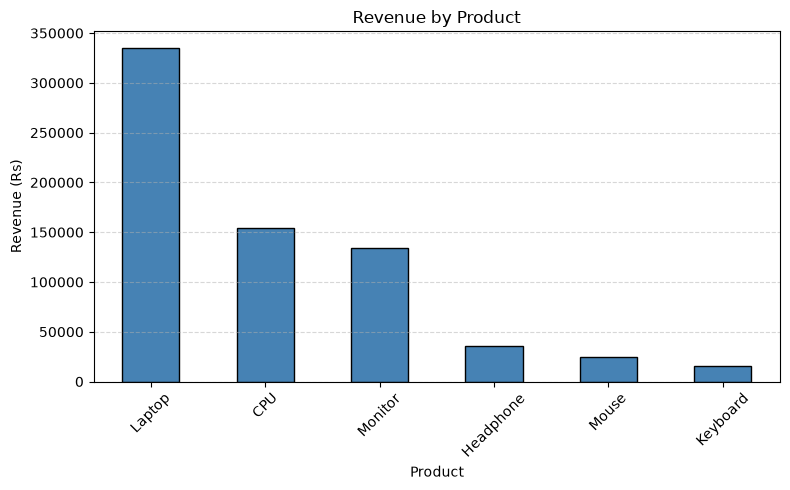

In [21]:
plt.figure(figsize=(8,5))

product_revenue.plot(kind="bar",color="steelblue",edgecolor="black")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (Rs)")

plt.xticks(rotation=45)
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.tight_layout()

plt.show()

### Observation

- Laptop generated the highest revenue (**Rs. 335,000**).
- CPU and Monitor were the second and third highest revenue-generating products.
- Mouse had the highest sales frequency, but its revenue was lower because of its lower selling price.
- This indicates that expensive products contribute more to total revenue even with fewer sales.

In [22]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Amount"].sum()

print(monthly_sales)

Date
2026-07    232500.0
2026-08    245800.0
2026-09    220400.0
Freq: M, Name: Amount, dtype: float64


## Monthly Sales Trend (Line Chart)

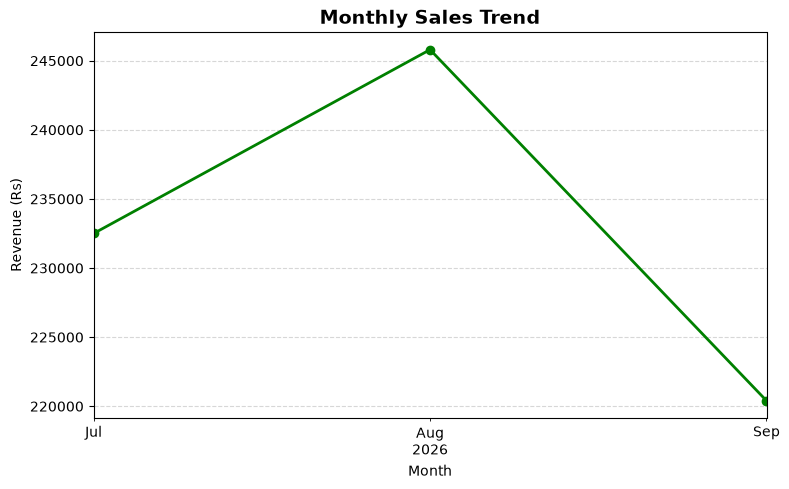

In [23]:
plt.figure(figsize=(8,5))

monthly_sales.plot(
    kind="line",
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (Rs)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observation

- The monthly sales trend shows how revenue changes over time.
- Revenue increased during some months while remaining lower in others.
- This trend helps identify high-performing months and supports future business planning.

## Sales Distribution by Region

This pie chart shows the percentage contribution of each region to the total sales revenue.

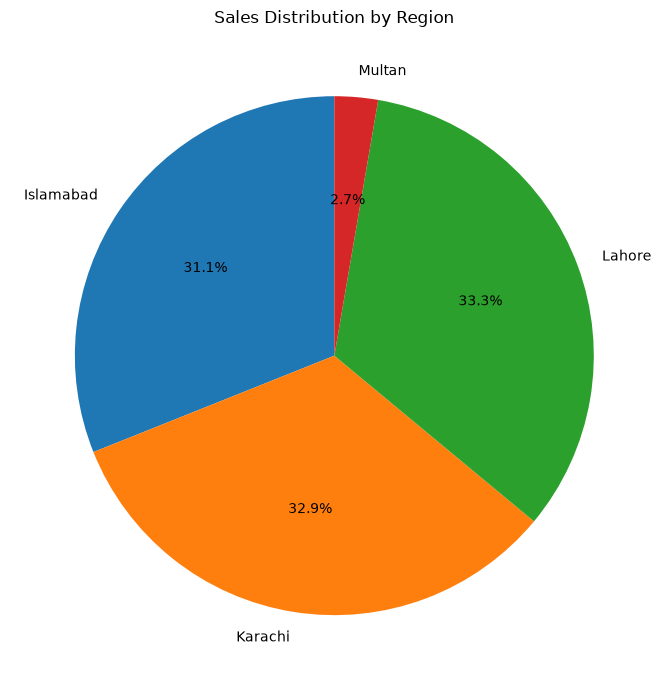

In [24]:
by_region = df.groupby("Region")["Amount"].sum()

plt.figure(figsize=(7,7))

by_region.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Region")

plt.ylabel("")

plt.tight_layout()
plt.show()

## Category Analysis

This section analyzes the overall performance of each product category based on total revenue and units sold.

In [25]:
by_category = df.groupby("Category").agg({
    "Amount": "sum",
    "Units": "sum"
})

print(by_category)

                  Amount  Units
Category                       
Accessories      75700.0     41
Computer Parts  154000.0      3
Electronics     469000.0     10


### Observation

- Electronics generated the highest revenue (**Rs. 469,000**) despite selling only **10 units**.
- Accessories sold the highest number of units (**41**), but generated comparatively lower revenue because of their lower selling prices.
- Computer Parts contributed a moderate amount of revenue with only **3 units sold**.
- This analysis shows that product price has a greater impact on revenue than sales quantity alone.

## Final Sales Analysis Report (Console Output)

The following report summarizes the key findings of the sales data analysis.

In [26]:
print("=" * 50)
print("SALES ANALYSIS REPORT")
print("=" * 50)

print(f"Total Records: {len(df)}")

print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")

print(f"Total Revenue: Rs {df['Amount'].sum():,.0f}")

print(f"Average Sale: Rs {df['Amount'].mean():,.2f}")

print(f"Median Sale: Rs {df['Amount'].median():,.0f}")

print("\nTop 5 Products by Revenue:")

print(df.groupby("Product")["Amount"].sum().nlargest(5))

best_month = df.groupby(df["Date"].dt.to_period("M"))["Amount"].sum().idxmax()

print(f"\nBest Sales Month: {best_month}")

SALES ANALYSIS REPORT
Total Records: 18
Date Range: 2026-07-01 to 2026-09-30
Total Revenue: Rs 698,700
Average Sale: Rs 38,816.67
Median Sale: Rs 13,000

Top 5 Products by Revenue:
Product
Laptop       335000.0
CPU          154000.0
Monitor      134000.0
Headphone     35600.0
Mouse         24200.0
Name: Amount, dtype: float64

Best Sales Month: 2026-08
